<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/NLP/NLP05/260910_Quest_Haena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1. 환경 설정
!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install sentencepiece

from google.colab import drive
drive.mount('/content/drive')

import os, re, random, tarfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sentencepiece as spm
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm

#plt.rcParams["font.family"] = "NanumGothic"
#plt.rcParams["axes.unicode_minus"] = False

#폰트 설정
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath) # 폰트를 matplotlib 에 등록
plt.rc('font', family=fm.FontProperties(fname=fontpath).get_name())
plt.rc('axes', unicode_minus=False)

print("환경설정 끝")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
Mounted at /content/drive
환경설정 끝
device: cuda


In [2]:
#2. 데이터 다운로드 + 중복 제거
DATA_DIR = "/content/drive/MyDrive/Aiffel_EPA/transformer/data"
os.makedirs(DATA_DIR, exist_ok=True)

URL = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-park.train.tar.gz"
ARCHIVE = os.path.join(DATA_DIR, "korean-english-park.train.tar.gz")

if not os.path.exists(ARCHIVE):
    !wget -q -O "$ARCHIVE" "$URL"

with tarfile.open(ARCHIVE, "r:gz") as tar:
    tar.extractall(DATA_DIR)

kor_path = os.path.join(DATA_DIR, "korean-english-park.train.ko")
eng_path = os.path.join(DATA_DIR, "korean-english-park.train.en")

with open(kor_path, encoding="utf-8") as f:
    kor_lines = [x.strip() for x in f]
with open(eng_path, encoding="utf-8") as f:
    eng_lines = [x.strip() for x in f]

assert len(kor_lines) == len(eng_lines)

# 한국어-영어 문장 쌍을 하나의 tuple로 묶은 뒤 중복 제거
seen = set()
cleaned_corpus = []

for ko, en in zip(kor_lines, eng_lines):
    pair = (ko, en)
    if pair not in seen:
        seen.add(pair)
        cleaned_corpus.append(pair)

print("원본:", len(kor_lines))
print("중복 제거 후:", len(cleaned_corpus))
print("\n예시")
print("KO:", cleaned_corpus[0][0])
print("EN:", cleaned_corpus[0][1])

/tmp/ipykernel_875/3289798801.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


원본: 94123
중복 제거 후: 78941

예시
KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
EN: Much of personal computing is about "can you top this?"


In [3]:
#3. 전처리 + SentencePiece
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()

src_texts = [preprocess_sentence(ko) for ko, _ in cleaned_corpus]
tgt_texts = [preprocess_sentence(en) for _, en in cleaned_corpus]

print("전처리 전:", cleaned_corpus[0][0])
print("전처리 후:", src_texts[0])
print()

def train_tokenizer(corpus, prefix, vocab_size=20000):
    txt = os.path.join(DATA_DIR, prefix + ".txt")
    model = os.path.join(DATA_DIR, prefix + ".model")

    with open(txt, "w", encoding="utf-8") as f:
        f.write("\n".join(corpus))

    for ext in [".model", ".vocab"]:
        path = os.path.join(DATA_DIR, prefix + ext)
        if os.path.exists(path):
            os.remove(path)

    spm.SentencePieceTrainer.train(
        input=txt,
        model_prefix=os.path.join(DATA_DIR, prefix),
        vocab_size=vocab_size,
        pad_id=0,
        bos_id=1,
        eos_id=2,
        unk_id=3,
        character_coverage=0.9995
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(model)
    return tokenizer

SRC_VOCAB_SIZE = 20000
TGT_VOCAB_SIZE = 20000

src_tokenizer = train_tokenizer(src_texts, "korean_src", SRC_VOCAB_SIZE)
tgt_tokenizer = train_tokenizer(tgt_texts, "english_tgt", TGT_VOCAB_SIZE)

print("Source vocab:", src_tokenizer.GetPieceSize())
print("Target vocab:", tgt_tokenizer.GetPieceSize())

test = src_tokenizer.EncodeAsIds(src_texts[0])
print("토큰 ID:", test[:10])
print("토큰:", src_tokenizer.EncodeAsPieces(src_texts[0])[:10])

전처리 전: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
전처리 후: 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?

Source vocab: 20000
Target vocab: 20000
토큰 ID: [1010, 284, 635, 576, 6, 8854, 8385, 9387, 223, 2927]
토큰: ['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분은', '▁이것', '보다', '▁뛰어']


In [4]:
#4. Dataset 구성
MAX_LEN = 50

src_corpus, tgt_corpus = [], []

for src, tgt in zip(src_texts, tgt_texts):
    src_ids = src_tokenizer.EncodeAsIds(src)
    tgt_ids = tgt_tokenizer.Encode(tgt, add_bos=True, add_eos=True)

    if len(src_ids) <= MAX_LEN and len(tgt_ids) <= MAX_LEN:
        src_corpus.append(src_ids)
        tgt_corpus.append(tgt_ids)

enc_train = pad_sequence(
    [torch.tensor(x) for x in src_corpus],
    batch_first=True, padding_value=0
)

dec_train = pad_sequence(
    [torch.tensor(x) for x in tgt_corpus],
    batch_first=True, padding_value=0
)

print("enc_train:", enc_train.shape)
print("dec_train:", dec_train.shape)
print("BOS:", dec_train[0, 0].item(), "EOS:", dec_train[0, -1].item())

enc_train: torch.Size([75542, 50])
dec_train: torch.Size([75542, 50])
BOS: 1 EOS: 0


In [5]:
#5. Transformer 모델
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        B, Lq, D = q.shape
        Lk = k.size(1)

        q = self.q_proj(q).view(B, Lq, self.n_heads, self.d_k).transpose(1, 2)
        k = self.k_proj(k).view(B, Lk, self.n_heads, self.d_k).transpose(1, 2)
        v = self.v_proj(v).view(B, Lk, self.n_heads, self.d_k).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.d_k)

        if mask is not None:
            score = score.masked_fill(mask, -1e9)

        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, v)

        # [B,H,L,D] -> [B,L,H,D] -> [B,L,d_model]
        out = out.transpose(1, 2).contiguous()
        B, L, H, D = out.shape
        out = out.view(B, L, H * D)

        return self.out_proj(out), attn


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        a, attn = self.attn(x, x, x, mask)
        x = self.norm1(x + self.drop(a))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, memory, self_mask, memory_mask):
        a, self_attn = self.self_attn(x, x, x, self_mask)
        x = self.norm1(x + self.drop(a))

        a, cross_attn = self.cross_attn(x, memory, memory, memory_mask)
        x = self.norm2(x + self.drop(a))

        x = self.norm3(x + self.drop(self.ffn(x)))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = self.drop(self.pos(self.embedding(x)))
        attentions = []

        for layer in self.layers:
            x, attn = layer(x, mask)
            attentions.append(attn)

        return x, attentions


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.drop = nn.Dropout(dropout)

    def forward(self, x, memory, self_mask, memory_mask):
        x = self.drop(self.pos(self.embedding(x)))
        self_attentions, cross_attentions = [], []

        for layer in self.layers:
            x, self_attn, cross_attn = layer(
                x, memory, self_mask, memory_mask
            )
            self_attentions.append(self_attn)
            cross_attentions.append(cross_attn)

        return x, self_attentions, cross_attentions


class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model, n_heads,
                 d_ff, n_layers, dropout):
        super().__init__()

        self.encoder = Encoder(
            src_vocab, d_model, n_heads, d_ff, n_layers, dropout
        )
        self.decoder = Decoder(
            tgt_vocab, d_model, n_heads, d_ff, n_layers, dropout
        )

        self.fc = nn.Linear(d_model, tgt_vocab)

        # 입력/출력 임베딩 weight 공유
        self.fc.weight = self.decoder.embedding.weight

        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1 and p is not self.decoder.embedding.weight:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        memory, enc_attn = self.encoder(src, src_mask)

        dec_out, dec_self_attn, cross_attn = self.decoder(
            tgt, memory, tgt_mask, memory_mask
        )

        return self.fc(dec_out), enc_attn, dec_self_attn, cross_attn

In [6]:
#6. Mask + 모델 생성 + 차원 확인
def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2)


def generate_causality_mask(size):
    return torch.triu(
        torch.ones(size, size, dtype=torch.bool),
        diagonal=1
    )


def generate_masks(src, tgt):
    src_mask = generate_padding_mask(src)

    tgt_pad = generate_padding_mask(tgt)
    tgt_causal = generate_causality_mask(tgt.size(1)).to(tgt.device)
    tgt_causal = tgt_causal.unsqueeze(0).unsqueeze(1)

    tgt_mask = tgt_pad | tgt_causal
    memory_mask = src_mask

    return src_mask, tgt_mask, memory_mask


# 하이퍼파라미터
N_LAYERS = 2
D_MODEL = 512
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.3

transformer = Transformer(
    SRC_VOCAB_SIZE, TGT_VOCAB_SIZE,
    D_MODEL, N_HEADS, D_FF,
    N_LAYERS, DROPOUT
).to(device)

sample_src = enc_train[:2].to(device)
sample_tgt = dec_train[:2, :-1].to(device)

src_mask, tgt_mask, memory_mask = generate_masks(
    sample_src, sample_tgt
)

with torch.no_grad():
    sample_out, _, _, _ = transformer(
        sample_src, sample_tgt,
        src_mask, tgt_mask, memory_mask
    )

print("src       :", sample_src.shape)
print("tgt       :", sample_tgt.shape)
print("src_mask  :", src_mask.shape)
print("tgt_mask  :", tgt_mask.shape)
print("output    :", sample_out.shape)

src       : torch.Size([2, 50])
tgt       : torch.Size([2, 49])
src_mask  : torch.Size([2, 1, 1, 50])
tgt_mask  : torch.Size([2, 1, 49, 49])
output    : torch.Size([2, 49, 20000])


In [7]:
#7. Loss + Noam Scheduler + 학습/번역 함수
criterion = nn.CrossEntropyLoss(ignore_index=0)

optimizer = optim.Adam(
    transformer.parameters(),
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

WARMUP_STEPS = 4000

def noam(step):
    step = max(step, 1)
    return D_MODEL ** -0.5 * min(
        step ** -0.5,
        step * WARMUP_STEPS ** -1.5
    )

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam)


def train_step(src, tgt):
    transformer.train()

    src = src.to(device)
    tgt = tgt.to(device)

    dec_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, dec_in)

    optimizer.zero_grad()

    logits, _, _, _ = transformer(
        src, dec_in,
        src_mask, tgt_mask, memory_mask
    )

    loss = criterion(
        logits.reshape(-1, logits.size(-1)),
        gold.reshape(-1)
    )

    loss.backward()
    optimizer.step()
    scheduler.step()

    return loss.item()


test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]


def translate(sentence, return_attention=False):
    transformer.eval()

    src_text = preprocess_sentence(sentence)
    src_ids = src_tokenizer.EncodeAsIds(src_text)

    if len(src_ids) > MAX_LEN:
        src_ids = src_ids[:MAX_LEN]

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_mask = generate_padding_mask(src)

    with torch.no_grad():
        memory, enc_attn = transformer.encoder(src, src_mask)

        dec_ids = [1]  # BOS

        for _ in range(MAX_LEN - 1):
            tgt = torch.tensor(
                [dec_ids], dtype=torch.long, device=device
            )

            _, tgt_mask, memory_mask = generate_masks(src, tgt)

            dec_out, self_attn, cross_attn = transformer.decoder(
                tgt, memory, tgt_mask, memory_mask
            )

            next_id = transformer.fc(dec_out[:, -1]).argmax(-1).item()
            dec_ids.append(next_id)

            if next_id == 2:
                break

    result = tgt_tokenizer.DecodeIds(dec_ids[1:-1])

    if return_attention:
        return result, src_ids, dec_ids, enc_attn, self_attn, cross_attn

    return result

In [8]:
#8. Transformer 학습
BATCH_SIZE = 64
EPOCHS = 15

indices = np.arange(len(enc_train))

for epoch in range(1, EPOCHS + 1):
    np.random.shuffle(indices)
    losses = []

    pbar = tqdm(
        range(0, len(indices), BATCH_SIZE),
        desc=f"Epoch {epoch}/{EPOCHS}"
    )

    for start in pbar:
        batch_idx = indices[start:start + BATCH_SIZE]

        loss = train_step(
            enc_train[batch_idx],
            dec_train[batch_idx]
        )

        losses.append(loss)
        pbar.set_postfix(
            loss=f"{loss:.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.6f}"
        )

    avg_loss = np.mean(losses)

    print(f"\nEpoch {epoch} 평균 Loss: {avg_loss:.4f}")

    for sentence in test_sentences:
        print(f"{sentence} → {translate(sentence)}")

    # epoch별 모델 저장
    save_path = os.path.join(
        DATA_DIR, f"transformer_epoch{epoch}.pt"
    )

    torch.save(transformer.state_dict(), save_path)
    print("저장:", save_path)

"""
    checkpoint = {
    "epoch": epoch,
    "model_state": transformer.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    }

    torch.save(checkpoint, save_path)
"""

Epoch 1/15:   0%|          | 0/1181 [00:00<?, ?it/s]


Epoch 1 평균 Loss: 34.2100
오바마는 대통령이다. → a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
시민들은 도시 속에 산다. → a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
커피는 필요 없다. → a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
일곱 명의 사망자가 발생했다. → a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
저장: /content/drive/MyDrive/Aiffel_EPA/transformer/data/transformer_epoch1.pt


Epoch 2/15:   0%|          | 0/1181 [00:00<?, ?it/s]


Epoch 2 평균 Loss: 11.0762
오바마는 대통령이다. → the is .
시민들은 도시 속에 산다. → the is , , the first .
커피는 필요 없다. → the is .
일곱 명의 사망자가 발생했다. → the is , , the first .
저장: /content/drive/MyDrive/Aiffel_EPA/transformer/data/transformer_epoch2.pt


Epoch 3/15:   0%|          | 0/1181 [00:00<?, ?it/s]

...


Epoch 13 평균 Loss: 5.0459
오바마는 대통령이다. → obama is a very good victory in the white house .
시민들은 도시 속에 산다. → the film is a very good thing .
커피는 필요 없다. → it s not a very good thing .
일곱 명의 사망자가 발생했다. → the incident occurred in the attack , which is , was in the capital of the capital , where the city of the capital of the capital , which is , the official said .
저장: /content/drive/MyDrive/Aiffel_EPA/transformer/data/transformer_epoch13.pt


Epoch 14/15:   0%|          | 0/1181 [00:00<?, ?it/s]


Epoch 14 평균 Loss: 5.0028
오바마는 대통령이다. → obama has a big lead in the white house .
시민들은 도시 속에 산다. → the other hand is a little bit of the world s most expensive .
커피는 필요 없다. → i m going to be a lot of people .
일곱 명의 사망자가 발생했다. → the attack occurred in the attack .
저장: /content/drive/MyDrive/Aiffel_EPA/transformer/data/transformer_epoch14.pt


Epoch 15/15:   0%|          | 0/1181 [00:00<?, ?it/s]


Epoch 15 평균 Loss: 4.9630
오바마는 대통령이다. → he has a big debate .
시민들은 도시 속에 산다. → the new york times s new york times .
커피는 필요 없다. → i don t think it s a lot of people .
일곱 명의 사망자가 발생했다. → the quake was .
저장: /content/drive/MyDrive/Aiffel_EPA/transformer/data/transformer_epoch15.pt



Epoch 14 모델로 최종 결과
오바마는 대통령이다. → obama has a big lead in the white house .
시민들은 도시 속에 산다. → the other hand is a little bit of the world s most expensive .
커피는 필요 없다. → i m going to be a lot of people .
일곱 명의 사망자가 발생했다. → the attack occurred in the attack .
입력: 오바마는 대통령이다.
번역: obama has a big lead in the white house .
Source tokens: ['오바마는', '대통령이', '다', '.']
Target tokens: ['<s>', 'obama', 'has', 'a', 'big', 'lead', 'in', 'the', 'white', 'house', '.', '</s>']


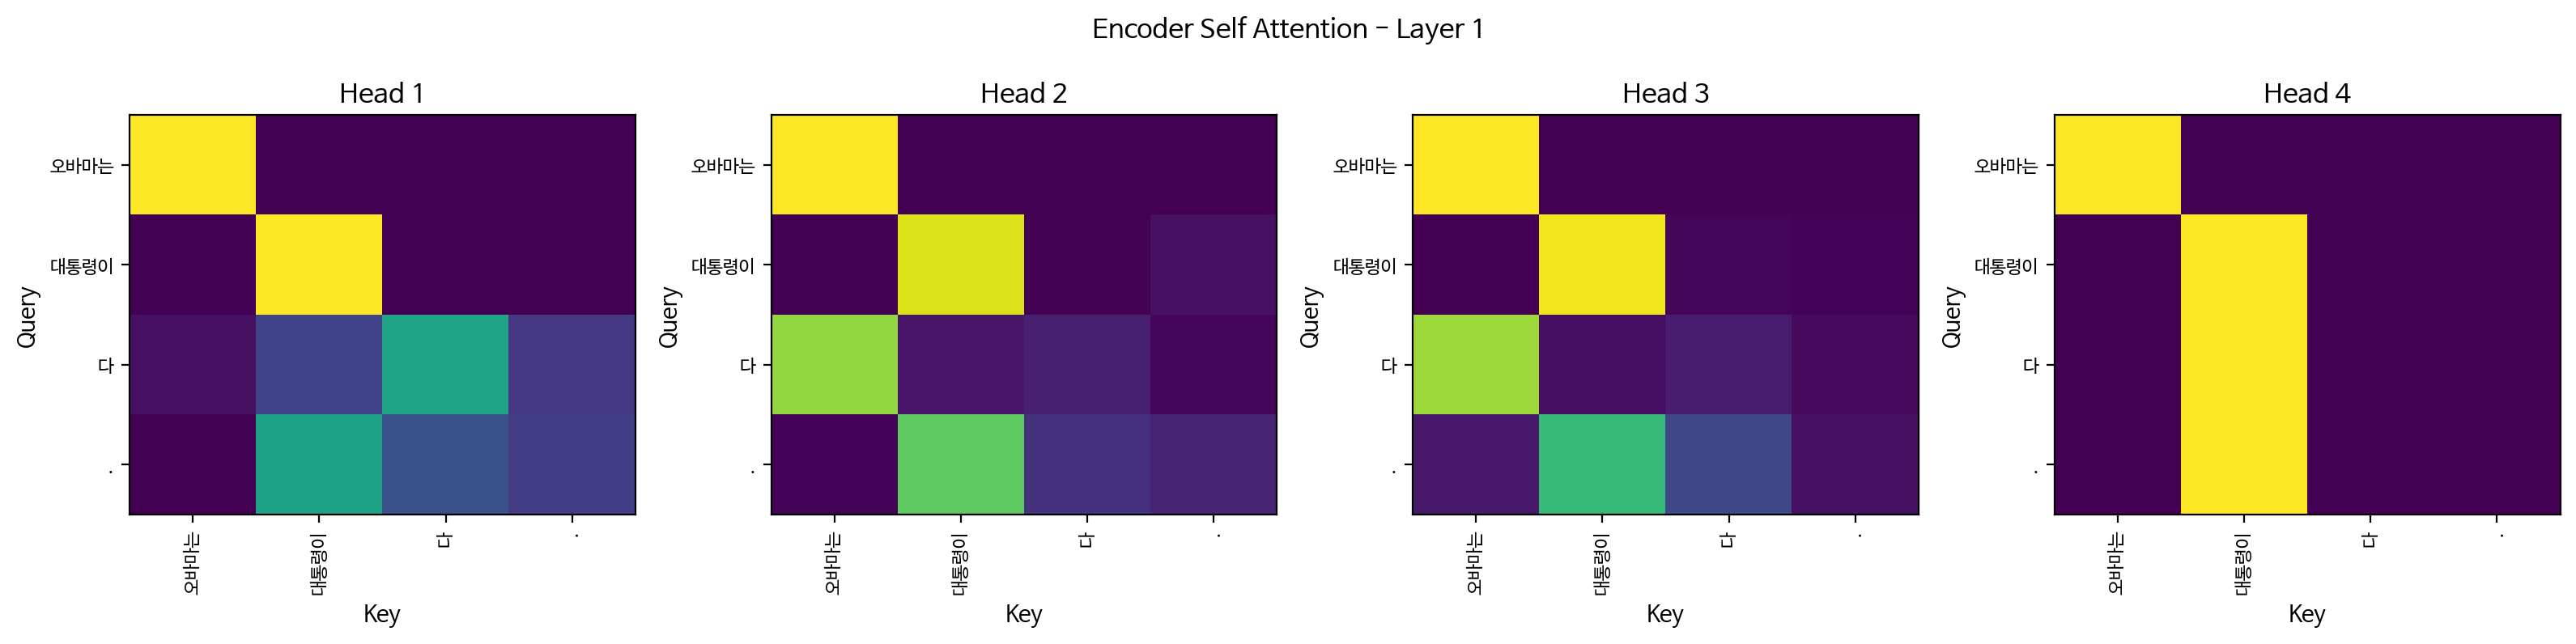

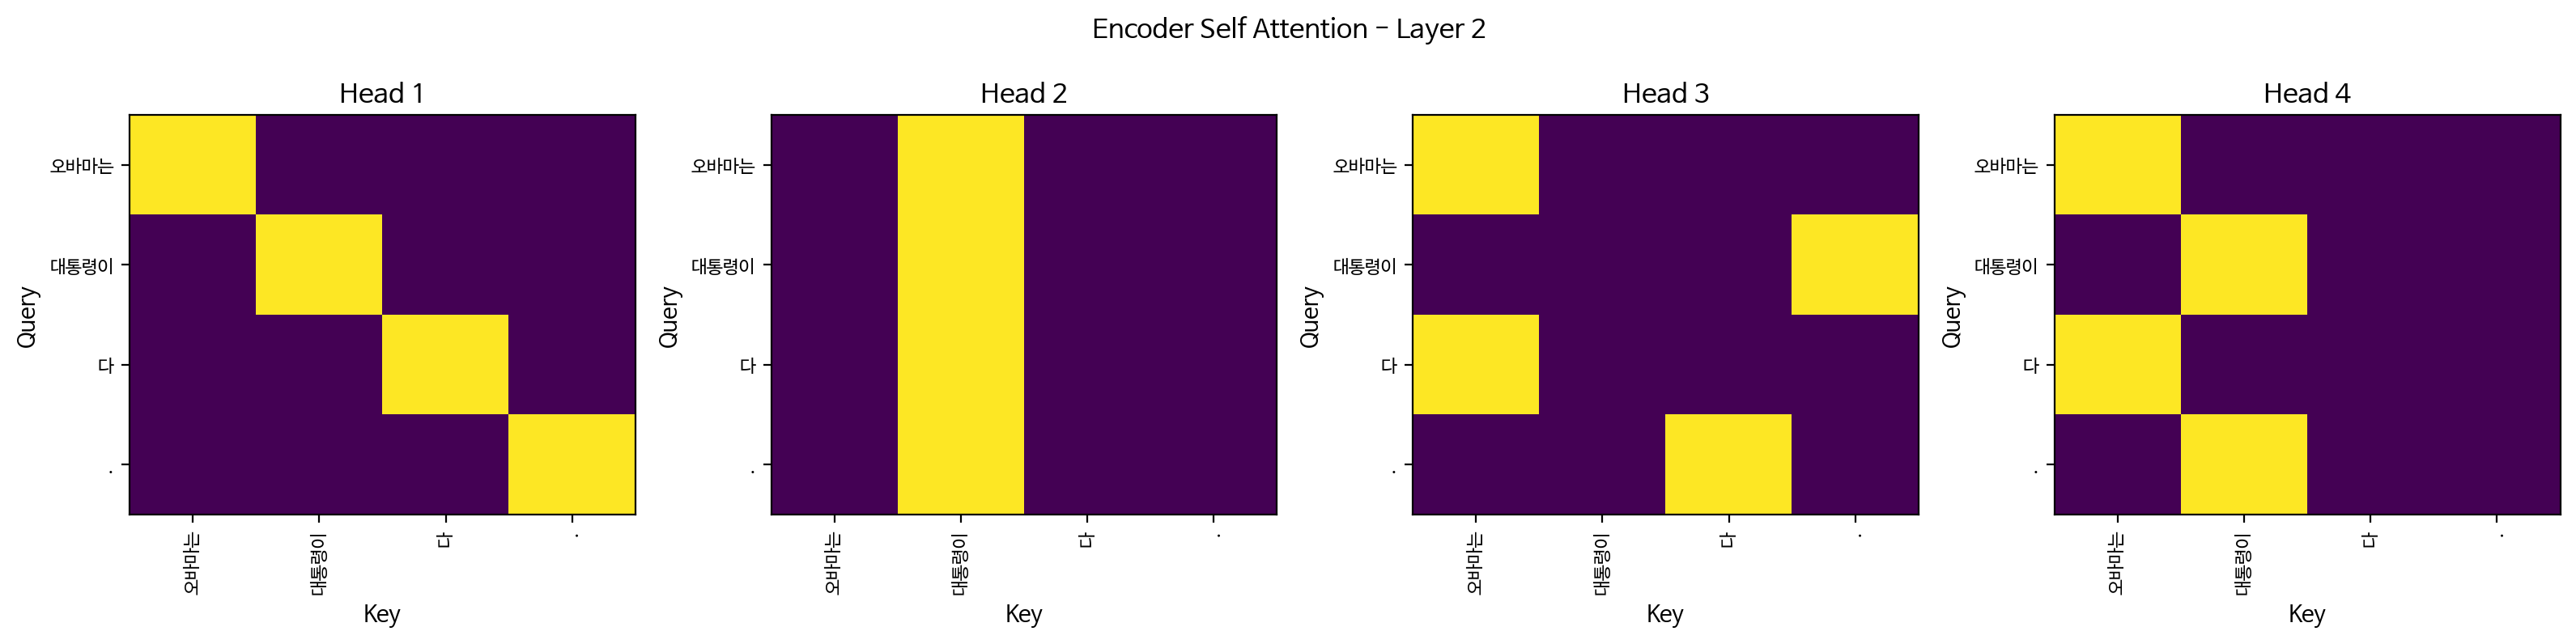

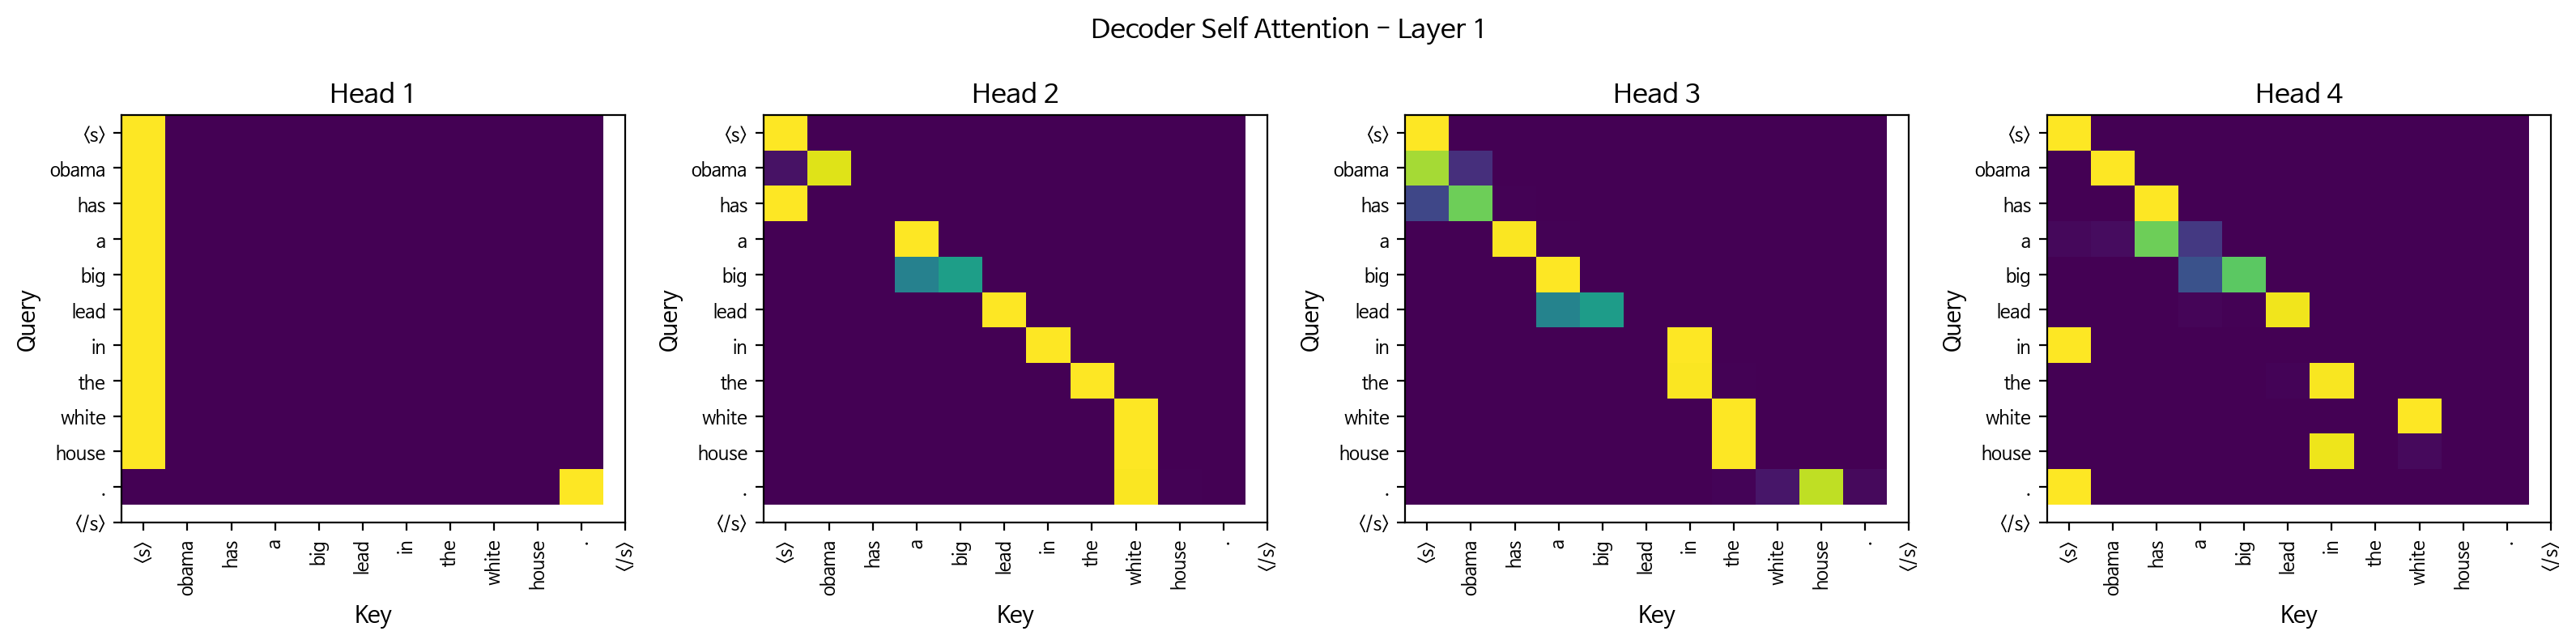

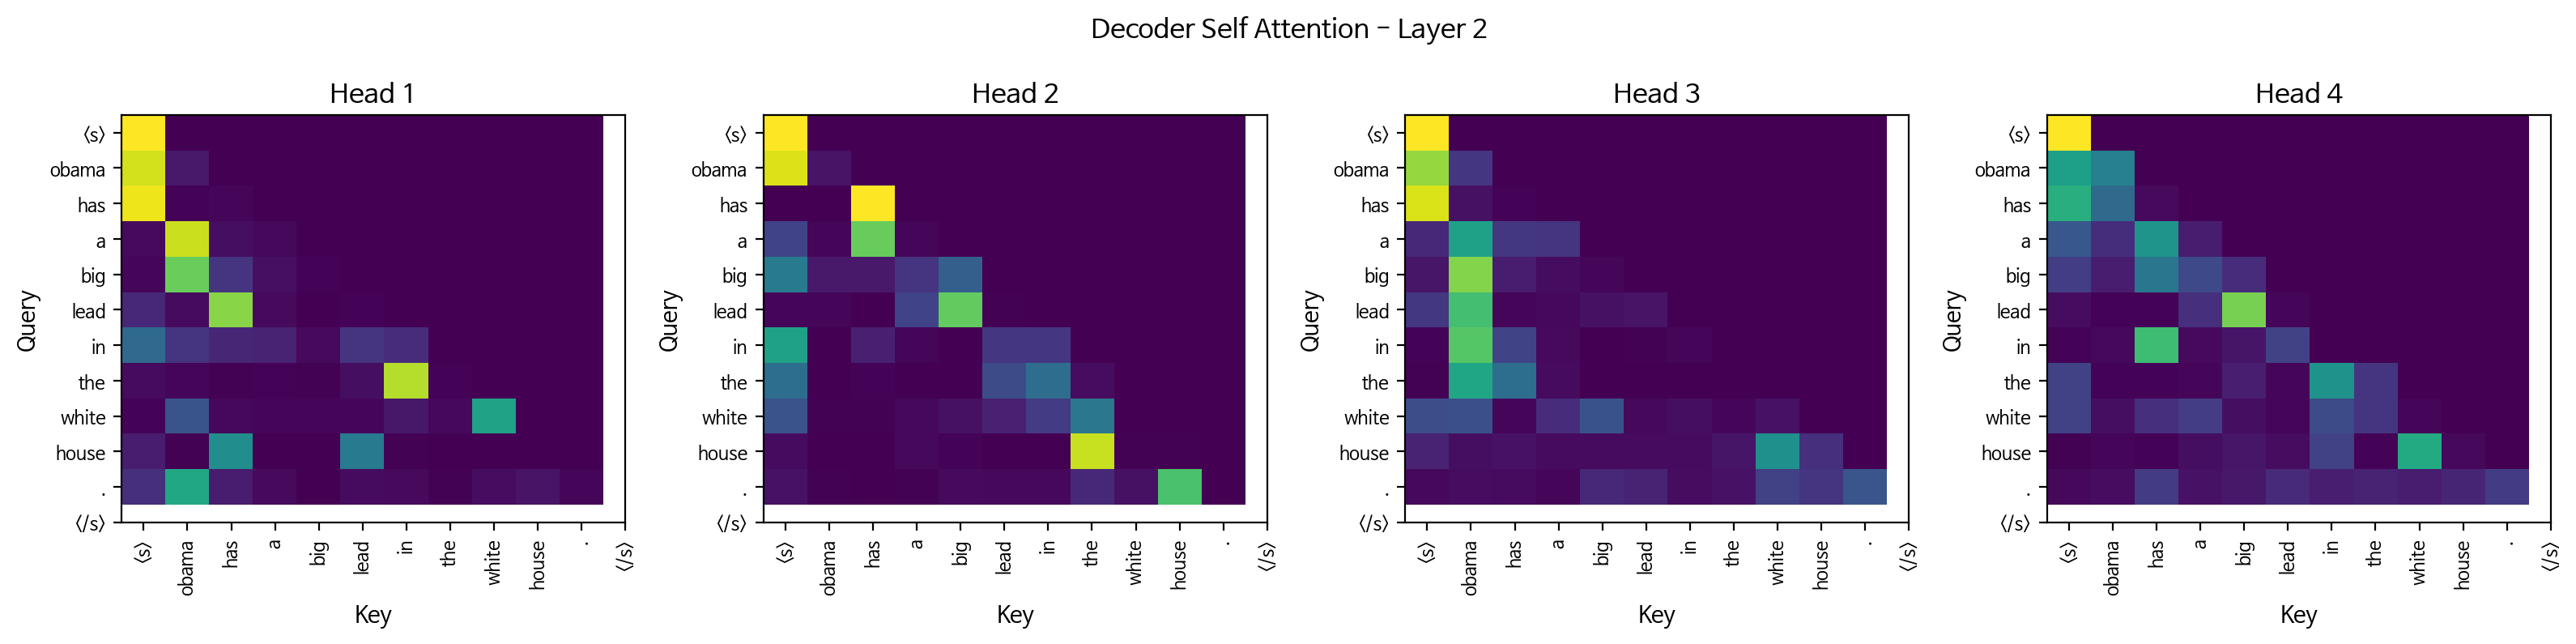

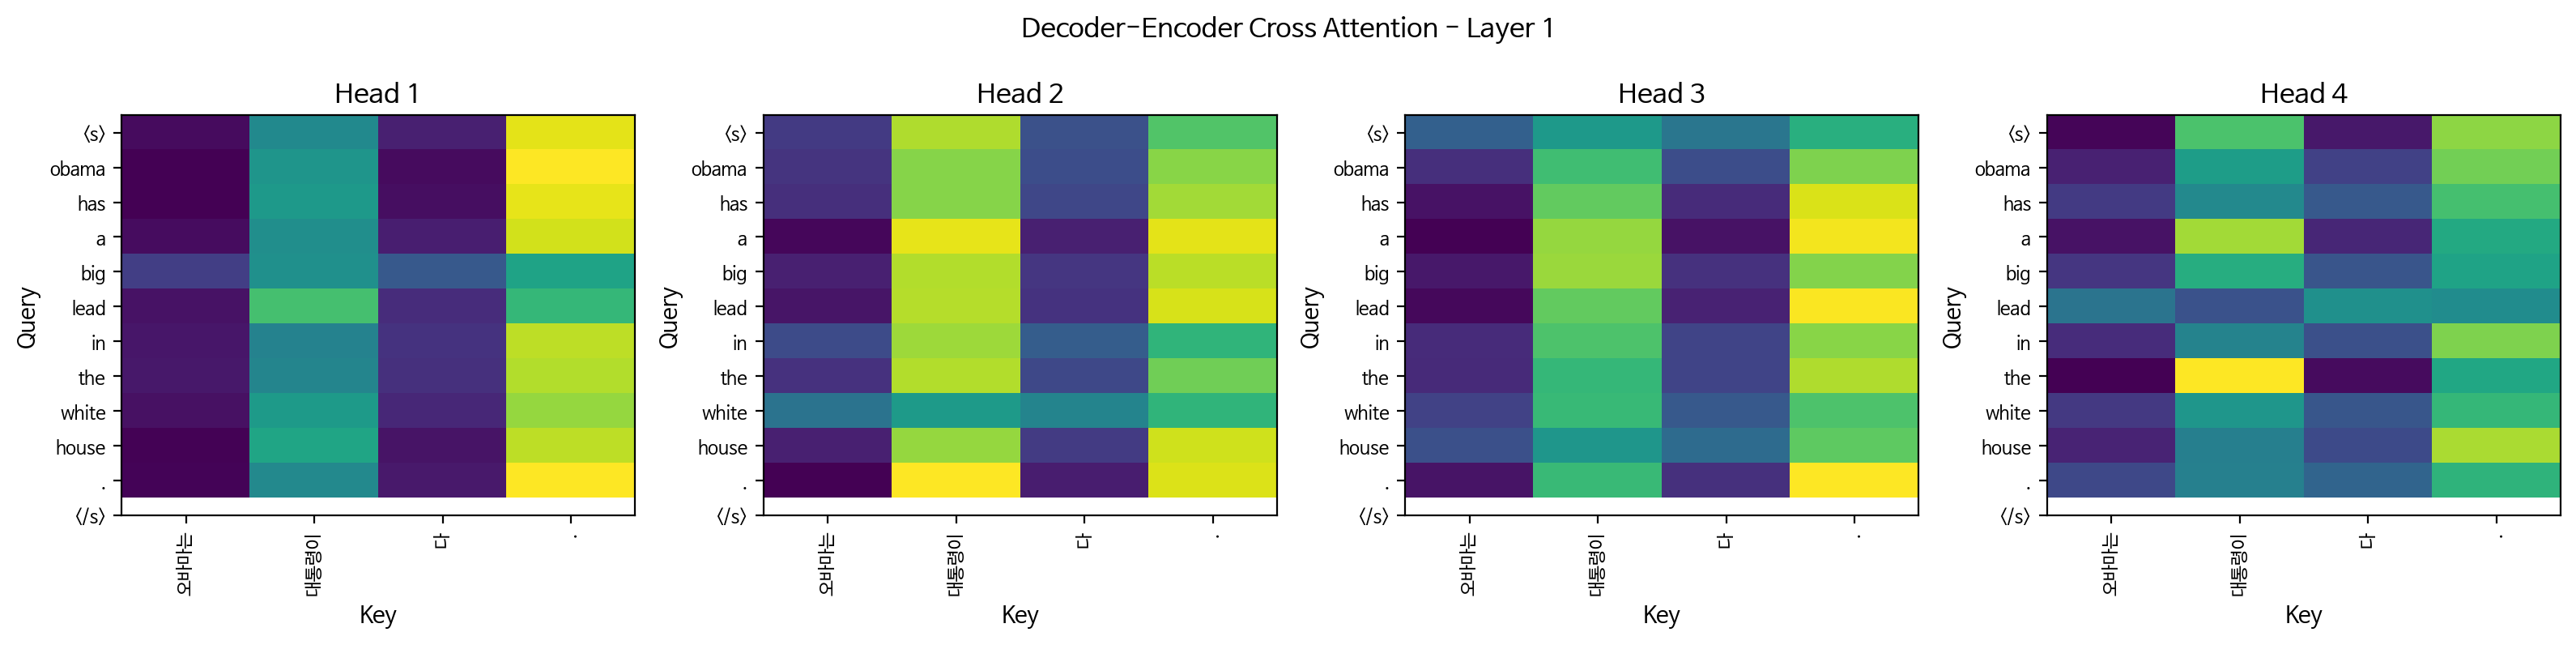

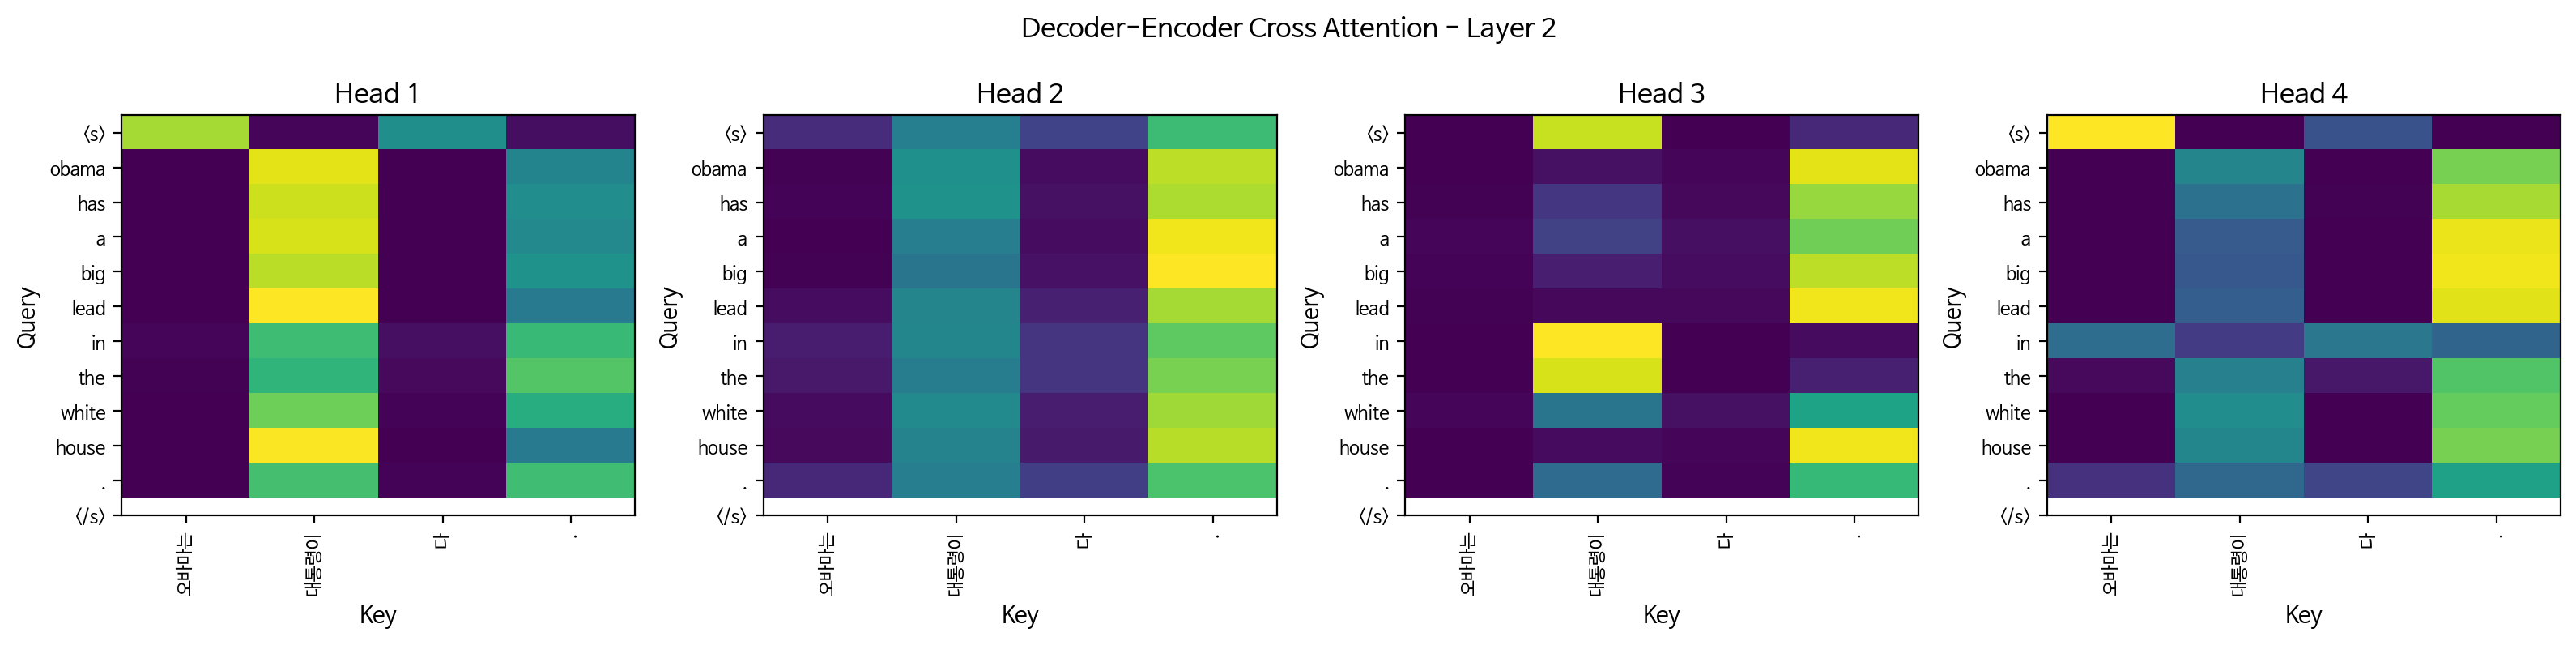

In [9]:
#9. Attention Map

BEST_EPOCH = 14
#BEST_EPOCH = EPOCHS

best_path = os.path.join(
    DATA_DIR, f"transformer_epoch{BEST_EPOCH}.pt"
)

transformer.load_state_dict(
    torch.load(best_path, map_location=device)
)

"""
checkpoint = torch.load(
    save_path,
    map_location=device
)

transformer.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])
scheduler.load_state_dict(checkpoint["scheduler_state"])

start_epoch = checkpoint["epoch"] + 1
"""


print(f"\nEpoch {BEST_EPOCH} 모델로 최종 결과")
for sentence in test_sentences:
    print(f"{sentence} → {translate(sentence)}")


def piece_labels(tokenizer, ids):
    return [
        tokenizer.IdToPiece(int(i)).replace("▁", "")
        for i in ids
    ]


def plot_attention(attentions, q_labels, k_labels, title):
    # attentions: [B,H,Q,K]
    weights = attentions[0].detach().cpu().numpy()

    fig, axes = plt.subplots(
        1, 4, figsize=(16, 4)
    )

    for h in range(4):
        axes[h].imshow(weights[h], aspect="auto")
        axes[h].set_title(f"Head {h + 1}")
        axes[h].set_xlabel("Key")
        axes[h].set_ylabel("Query")
        axes[h].set_xticks(range(len(k_labels)))
        axes[h].set_xticklabels(
            k_labels, rotation=90, fontsize=8
        )
        axes[h].set_yticks(range(len(q_labels)))
        axes[h].set_yticklabels(
            q_labels, fontsize=8
        )

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


sentence = test_sentences[0]

result, src_ids, dec_ids, enc_attn, dec_self_attn, cross_attn = \
    translate(sentence, return_attention=True)

src_labels = piece_labels(src_tokenizer, src_ids)
tgt_labels = piece_labels(tgt_tokenizer, dec_ids)

print("입력:", sentence)
print("번역:", result)
print("Source tokens:", src_labels)
print("Target tokens:", tgt_labels)

for layer in range(N_LAYERS):
    plot_attention(
        enc_attn[layer],
        src_labels,
        src_labels,
        f"Encoder Self Attention - Layer {layer + 1}"
    )

for layer in range(N_LAYERS):
    plot_attention(
        dec_self_attn[layer],
        tgt_labels,
        tgt_labels,
        f"Decoder Self Attention - Layer {layer + 1}"
    )

for layer in range(N_LAYERS):
    plot_attention(
        cross_attn[layer],
        tgt_labels,
        src_labels,
        f"Decoder-Encoder Cross Attention - Layer {layer + 1}"
    )

#1. 하이퍼파라미터

| 항목                    |                값 |
| --------------------- | ---------------: |
| Encoder/Decoder Layer |                2 |
| `d_model`             |              512 |
| `n_heads`             |                8 |
| `d_ff`                |             2048 |
| Dropout               |              0.3 |
| Warm-up               |             4000 |
| Batch Size            |               64 |
| Epoch                 |                5 |
| Optimizer             |             Adam |
| Adam β                |    `(0.9, 0.98)` |
| Adam ε                |           `1e-9` |
| Loss                  | CrossEntropyLoss |
| Padding               | `ignore_index=0` |
| Vocabulary            |           20,000 |
| Max token length      |               50 |


## Attention Map은 총 6개
Encoder Self Attention × 2 layers

Decoder Self Attention × 2 layers

Decoder-Encoder Cross Attention × 2 layers


#2. 생성된 번역

| 입력               | 모델 생성 결과 |
| ---------------- | -------- |
| 오바마는 대통령이다.      | obama has a big lead in the white house .    |
| 시민들은 도시 속에 산다.   | the other hand is a little bit of the world s most expensive . |
| 커피는 필요 없다.       | i m going to be a lot of people .  |
| 일곱 명의 사망자가 발생했다. | the attack occurred in the attack .  |

#3. Attention Map 해석
Encoder Self Attention에서는 Layer 1에서 각 토큰의 자기 자신 및 인접 토큰에 대한 Attention이 비교적 뚜렷하게 나타났으며, Layer 2에서는 Head별로 서로 다른 Attention 패턴이 관찰되었다. 이를 통해 Encoder가 여러 Attention Head를 이용하여 입력 문장의 토큰 간 관계를 다양한 관점에서 처리하고 있음을 확인할 수 있었다.

Decoder Self Attention에서는 Causal Mask의 영향으로 미래 토큰에 해당하는 오른쪽 위 영역의 Attention이 차단되는 모습을 확인할 수 있었다. 또한 Layer 2에서는 이전에 생성된 여러 토큰으로 Attention이 분산되는 모습을 보여, 현재 토큰뿐 아니라 앞에서 생성된 문맥을 함께 활용하고 있음을 확인할 수 있었다.

Decoder-Encoder Cross Attention에서는 영어 토큰을 생성하는 과정에서 한국어 입력의 특정 토큰에 Attention이 집중되는 현상이 나타났다. 특히 여러 Head에서 대통령이 부분에 상대적으로 높은 Attention이 나타났으며, Head에 따라 Attention 분포에는 차이가 있었다. 이는 Decoder가 영어를 생성할 때 Encoder가 처리한 한국어의 특정 부분을 선택적으로 참고하고 있음을 보여준다.

다만 본 실험의 번역 결과는 obama has a big lead in the white house.로 나타나 입력 문장인 오바마는 대통령이다.의 의미를 정확하게 보존하지 못했다. 따라서 Attention Map에서 특정 토큰 간의 명확한 번역 대응 관계가 완전히 형성되었다고 판단하기는 어려우며, 학습 횟수나 데이터 및 하이퍼파라미터에 따른 추가적인 성능 개선이 필요하다.

